In [1]:
import gymnasium_env as drausp_env
import numpy as np
from pathlib import Path

from instance_reader import get_instance_data
import matplotlib.pyplot as plt

data_path = Path("../instances/lion18s/SA01.txt")

In [2]:
DRAUSP_data = get_instance_data(data_path)

K = DRAUSP_data.num_slots
T_d = DRAUSP_data.num_requests
C_k = DRAUSP_data.capacity_vector
instance = DRAUSP_data.instance
print(K)
print(T_d)
print(C_k)
print(instance)

4
50
[10, 10, 10, 10]
[[41, 1, 1, 0, 0], [39, 1, 1, 0, 0], [20, 1, 3, 0, 0], [61, 2, 1, 0, 0], [18, 2, 1, 0, 0], [23, 1, 4, 0, 0], [25, 1, 1, 0, 0], [13, 1, 1, 0, 0], [77, 1, 1, 0, 0], [8, 1, 2, 0, 0], [25, 1, 3, 0, 0], [74, 1, 1, 0, 0], [39, 1, 3, 0, 0], [54, 3, 2, 0, 0], [70, 1, 3, 0, 0], [71, 1, 1, 0, 0], [55, 1, 1, 0, 0], [9, 1, 1, 0, 0], [96, 1, 1, 0, 0], [63, 3, 2, 0, 0], [50, 3, 2, 0, 0], [20, 1, 1, 0, 0], [43, 1, 2, 0, 0], [74, 1, 2, 0, 0], [62, 1, 1, 0, 0], [60, 1, 1, 0, 0], [22, 1, 1, 0, 0], [81, 1, 2, 0, 0], [92, 1, 1, 0, 0], [80, 1, 1, 0, 0], [38, 2, 1, 0, 0], [84, 1, 1, 0, 0], [39, 1, 2, 0, 0], [88, 2, 1, 0, 0], [69, 1, 3, 0, 0], [21, 2, 1, 0, 0], [15, 1, 1, 0, 0], [47, 3, 1, 0, 0], [67, 1, 1, 0, 0], [18, 1, 1, 0, 0], [87, 1, 1, 0, 0], [58, 1, 2, 0, 0], [34, 2, 1, 0, 0], [8, 1, 1, 0, 0], [97, 1, 1, 0, 0], [73, 1, 1, 0, 0], [54, 1, 1, 0, 0], [69, 2, 1, 0, 0], [79, 1, 2, 0, 0], [9, 1, 2, 0, 0]]


In [3]:
env = drausp_env.DrauspEnv(K=K, T_d=T_d, C_k=C_k, instance=instance, render_mode="human", fixed_request_length=2)

## Hier kann getestet werden ob alle Transitions korrekt funktionieren
Mit render bekommt man eine Übersicht was gerade los ist

In [4]:
obs, info = env.reset()
print(obs)
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
print(terminated)
env.render()

[ 1. 10. 10. 10. 10. 41.  1.  1.  0.  0.]
t=2    Caps=[9, 9, 10, 10]  r=39.00  q=[1, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=3    Caps=[8, 8, 10, 10]  r=20.00  q=[1, 3, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=4    Caps=[7, 5, 10, 10]  r=61.00  q=[2, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=5    Caps=[5, 4, 10, 10]  r=18.00  q=[2, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=6    Caps=[3, 3, 10, 10]  r=23.00  q=[1, 4, 0, 0]  Valid Actions: [0, 2, 3]
True
t=7    Caps=[2, -1, 10, 10]  r=25.00  q=[1, 1, 0, 0]  Valid Actions: [0, 3]


In [5]:
from dqn_agent import DQNAgent
from standard_dqn import DQNNetwork
agent = DQNAgent(env, QnetworkClass=DQNNetwork, monotonicity_penalty=False)

In [6]:
reward_history, monotonicity_violations = agent.train(num_episodes=1000)

  → Monotonie-Check (Episode    1): 68.6% korrekt (100 Paare)
 Systematic monotoncity evaluation (Episode 1):  Monotonie: 63.5%
  → Monotonie-Check (Episode    2): 62.5% korrekt (100 Paare)
 Systematic monotoncity evaluation (Episode 2):  Monotonie: 63.5%
  → Monotonie-Check (Episode    3): 62.2% korrekt (100 Paare)
 Systematic monotoncity evaluation (Episode 3):  Monotonie: 63.5%
  → Monotonie-Check (Episode    4): 62.9% korrekt (100 Paare)
 Systematic monotoncity evaluation (Episode 4):  Monotonie: 63.5%
  → Monotonie-Check (Episode    5): 68.2% korrekt (100 Paare)
 Systematic monotoncity evaluation (Episode 5):  Monotonie: 63.5%
  → Monotonie-Check (Episode    6): 71.8% korrekt (100 Paare)
 Systematic monotoncity evaluation (Episode 6):  Monotonie: 63.5%
  → Monotonie-Check (Episode    7): 68.8% korrekt (100 Paare)
 Systematic monotoncity evaluation (Episode 7):  Monotonie: 63.5%
  → Monotonie-Check (Episode    8): 65.7% korrekt (100 Paare)
 Systematic monotoncity evaluation (Episod

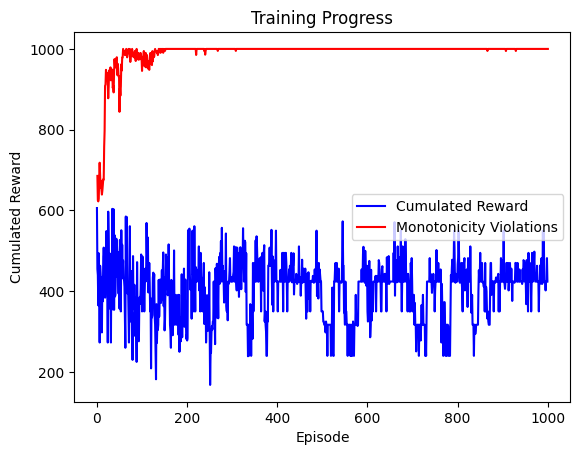

In [7]:
plt.plot(reward_history, color = "blue", label="Cumulated Reward")
plt.plot([x[0] for x in monotonicity_violations], [x[1]*1000 for x in monotonicity_violations], color = "red", label="Monotonicity Violations")
plt.xlabel("Episode")
plt.ylabel("Cumulated Reward")
plt.title("Training Progress")
plt.legend()
plt.show()

## Standard DQN scheint nicht (gut) zu funktionieren 
Negative kummulierte Rewards, der Agent kann nur durch Ausprobieren lernen welche Actions unzulässig sind, braucht lange und ist noisy!

In [8]:
env = drausp_env.DrauspEnv(K=K, T_d=T_d, C_k=C_k, instance=instance, render_mode="human", fixed_request_length=2)

In [ ]:
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt
import numpy as np

# Callback der die Rewards speichert
class RewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self._current_reward = 0.0

    def _on_step(self) -> bool:
        self._current_reward += self.locals["rewards"][0]
        if self.locals["dones"][0]:
            self.episode_rewards.append(self._current_reward)
            self._current_reward = 0.0
        return True

# Training mit bestehender env
callback = RewardCallback()
model = DQN("MlpPolicy", env, verbose=1, exploration_fraction=0.4, exploration_final_eps=0.05)
model.learn(total_timesteps=200_000, log_interval=4, callback=callback)

# Plot
plt.plot(callback.episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Cumulated Reward")
plt.title("Training Progress (SB3 DQN)")
plt.show()

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 12.2     |
|    ep_rew_mean      | 244      |
|    exploration_rate | 0.999    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 5795     |
|    time_elapsed     | 0        |
|    total_timesteps  | 49       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 12.8     |
|    ep_rew_mean      | 283      |
|    exploration_rate | 0.999    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 12064    |
|    time_elapsed     | 0        |
|    total_timesteps  | 102      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 12.2     |
|    ep_rew_mean      | 269    